# G1 Humanoid Mocap Tracking with MPPI

This notebook walks through:
1. Installing `mpc-warp` and its dependencies
2. Instantiating `G1MocapTracking` (downloads a walking reference automatically)
3. Running MPPI with `WarpMPPISolver` (GPU via CUDA / CPU Warp kernels)
4. Plotting the cost breakdown and pelvis height inline

The task tracks a walking reference from the [LocoMuJoCo](https://huggingface.co/datasets/robfiras/loco-mujoco-datasets) dataset on the Unitree G1 23-DOF humanoid model.

> **Google Colab GPU**: Runtime → Change runtime type → **T4 GPU** before running.
> The solver automatically picks `cuda:0` when a GPU is present.

## 1 · Install dependencies

One cell installs `mpc-warp` from GitHub (pulls in MuJoCo, mujoco-warp, mjviser, etc. from `pyproject.toml`) plus `matplotlib` for the cost plots at the end.

In [1]:
!pip install -q uv

!uv pip install -q --reinstall \
    "git+https://github.com/Vittorio-Caggiano/mpc-warp.git@main" \
    matplotlib

# On Colab: Runtime → Restart session after this cell, then re-run from cell 2.
print("Install complete.")


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Install complete.


## 2 · Verify GPU availability

In [2]:
import warp as wp

wp.init()
device = wp.get_device().alias
print("Warp device:", device)

Warp 1.13.0 initialized:
   CUDA not enabled in this build
   Devices:
     "cpu"      : "arm"
   Kernel cache:
     /Users/caggiano/Library/Caches/warp/1.13.0
Warp device: cpu


## 3 · Create the task and environment

`G1MocapTracking` pairs the Unitree G1 model with a reference-tracking cost. On construction it downloads a walking motion-capture clip and precomputes reference body positions and orientations for every frame.

The running cost is a normalised sum of four exponential-kernel terms:

| Term | What it penalises |
|---|---|
| `body_position` | World-frame body CoM positions (30 bodies) |
| `body_orientation` | World-frame body quaternions (30 bodies) |
| `configuration` | Joint positions (qpos) |
| `velocity` | Joint velocities (qvel) |

Each term lies in `[0, 1]` via `1 − exp(−squared_error)`. Call `task.advance()` after each `env.step()` to keep the reference in sync.

In [3]:
from mpc_warp.envs.mujoco_env import MujocoTaskEnv
from mpc_warp.tasks.g1_mocap import G1MocapTracking

# Downloads ~15 MB reference file on first run (cached to ~/.cache/huggingface)
task = G1MocapTracking()
env = MujocoTaskEnv(task)
env.reset()

print(f"nq={task.mj_model.nq}  nv={task.mj_model.nv}  nu={task.mj_model.nu}")
print(f"Reference: {task._n_frames} frames at {task._ref_fps:.0f} Hz  ({task._n_frames / task._ref_fps:.1f} s)")
print(f"Bodies tracked: {task._nbody_tracked}")
print(
    f"Cost weights — body_pos={task._w_xpos:.4f}  body_ori={task._w_xquat:.4f}  "
    f"config={task._w_qpos:.4f}  vel={task._w_qvel:.4f}"
)
print(f"Pelvis height at frame 0: {env.data.qpos[2]:.3f} m")

/Users/caggiano/Dropbox/Myo/mpc-warp/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


nq=30  nv=29  nu=23
Reference: 10451 frames at 40 Hz  (261.3 s)
Bodies tracked: 30
Cost weights — body_pos=0.8264  body_ori=0.0826  config=0.0826  vel=0.0083
Pelvis height at frame 0: 0.817 m


## 4 · Create the MPPI solver

`WarpMPPISolver` allocates `num_samples` parallel MuJoCo worlds on the Warp device.
Each `solver.command(env.data)` call:
1. Uploads the current state to all worlds
2. Rolls out `horizon` steps in parallel
3. Weights samples by `exp(−cost / temperature)`
4. Returns the first action of the updated nominal trajectory

In [4]:
from mpc_warp.solvers.mppi_warp import WarpMPPIConfig, WarpMPPISolver

num_samples = 64 if device == "cpu" else 256

cfg = WarpMPPIConfig(
    horizon=32,
    num_samples=num_samples,
    noise_sigma=0.3,
    temperature=0.05,
    nominal_return=0.0,
)
solver = WarpMPPISolver(task, cfg, seed=0)
print(f"Solver device: {solver.device}  |  num_samples: {num_samples}")
print("Note: first command() call compiles Warp kernels — expect ~1 min on a cold Colab.")

Solver device: cpu  |  num_samples: 64
Note: first command() call compiles Warp kernels — expect ~1 min on a cold Colab.


## 5 · Run the control loop

Each iteration: `solver.command` → `env.step` → `task.advance()` (advances the reference frame counter).

In [5]:
NUM_STEPS = 200
LOG_EVERY = 50

costs_total = []
costs_body_pos = []
costs_body_ori = []
costs_config = []
costs_vel = []
pelvis_heights = []

env.reset()

for step_i in range(NUM_STEPS):
    u = solver.command(env.data)
    env.step(u)
    task.advance()  # advance reference frame — must be called after env.step()

    terms = task.cost_terms(env.data, u)
    total = sum(terms.values())

    costs_total.append(total)
    costs_body_pos.append(terms["body_position"])
    costs_body_ori.append(terms["body_orientation"])
    costs_config.append(terms["configuration"])
    costs_vel.append(terms["velocity"])
    pelvis_heights.append(float(env.data.qpos[2]))

    if (step_i + 1) % LOG_EVERY == 0:
        print(
            f"step {step_i + 1:4d}  "
            f"total={total:.4f}  "
            f"body_pos={terms['body_position']:.4f}  "
            f"body_ori={terms['body_orientation']:.4f}  "
            f"config={terms['configuration']:.4f}  "
            f"vel={terms['velocity']:.4f}  "
            f"pelvis_z={env.data.qpos[2]:.3f} m"
        )

print(f"\nDone — {NUM_STEPS} steps")

Module mujoco_warp._src.smooth 1c81c4c load on device 'cpu' took 2.48 ms  (cached)
Module mujoco_warp._src.collision_driver b8a4916 load on device 'cpu' took 0.71 ms  (cached)
Module _nxn_broadphase__locals__kernel_d86cb85d 1a81542 load on device 'cpu' took 0.55 ms  (cached)
Module _primitive_narrowphase__locals__primitive_narrowphase_9743b54a b3ead9d load on device 'cpu' took 0.62 ms  (cached)
Module mujoco_warp._src.constraint 43ba51e load on device 'cpu' took 1.74 ms  (cached)
Module _efc_contact_init__locals__kernel_9ba4ce0a e73c7ae load on device 'cpu' took 0.93 ms  (cached)
Module _efc_contact_jac_dense__locals__kernel_01c4be66 4728262 load on device 'cpu' took 0.87 ms  (cached)
Module _efc_contact_update__locals__kernel_17621467 116f9de load on device 'cpu' took 0.59 ms  (cached)
Module mujoco_warp._src.sensor 293b8fc load on device 'cpu' took 1.61 ms  (cached)
Module mujoco_warp._src.forward 4da183b load on device 'cpu' took 0.57 ms  (cached)
Module mujoco_warp._src.passive 297

## 6 · Plot cost breakdown and pelvis height

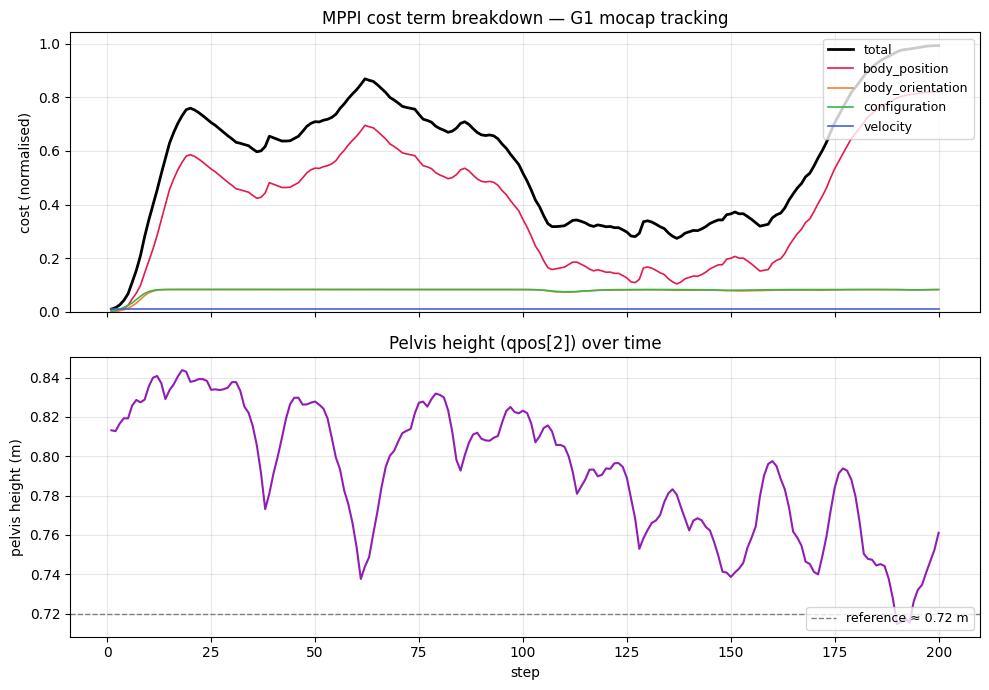

In [6]:
import matplotlib.pyplot as plt

steps = list(range(1, NUM_STEPS + 1))

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

ax = axes[0]
ax.plot(steps, costs_total, label="total", color="black", linewidth=2)
ax.plot(steps, costs_body_pos, label="body_position", color="#e6194b", linewidth=1.2)
ax.plot(steps, costs_body_ori, label="body_orientation", color="#f58231", linewidth=1.2)
ax.plot(steps, costs_config, label="configuration", color="#3cb44b", linewidth=1.2)
ax.plot(steps, costs_vel, label="velocity", color="#4363d8", linewidth=1.2)
ax.set_ylabel("cost (normalised)")
ax.set_title("MPPI cost term breakdown — G1 mocap tracking")
ax.legend(loc="upper right", fontsize=9)
ax.set_ylim(0, None)
ax.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.plot(steps, pelvis_heights, color="#911eb4", linewidth=1.5)
ax2.axhline(0.72, color="gray", linestyle="--", linewidth=1, label="reference ≈ 0.72 m")
ax2.set_xlabel("step")
ax2.set_ylabel("pelvis height (m)")
ax2.set_title("Pelvis height (qpos[2]) over time")
ax2.legend(loc="lower right", fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7 · Inspect per-body position errors

In [7]:
import mujoco
import numpy as np

t = task._ref_idx  # current reference frame after the run above

actual_xipos = env.data.xipos[1:]  # (30, 3) — skip world body
ref_xipos = task.ref_xpos[t]  # (30, 3)
per_body_err = np.linalg.norm(actual_xipos - ref_xipos, axis=1)

worst_idx = np.argsort(per_body_err)[::-1][:5]
print("Top-5 bodies by position error at the last step:")
for i in worst_idx:
    bname = mujoco.mj_id2name(task.mj_model, mujoco.mjtObj.mjOBJ_BODY, i + 1)
    print(f"  {bname:30s}  err = {per_body_err[i]:.4f} m")

Top-5 bodies by position error at the last step:
  left_ankle_roll_link            err = 0.9908 m
  left_ankle_pitch_link           err = 0.9328 m
  left_knee_link                  err = 0.7054 m
  left_hip_yaw_link               err = 0.5342 m
  right_wrist_yaw_link            err = 0.4170 m


## Next steps

- **Try a different motion clip**: pass another `reference_filename` from the LocoMuJoCo dataset (`run1`, `dance1`, `jump1`, …).
- **Tune the solver**: increase `num_samples` to 512–1024 on a GPU; lower `temperature` to tighten tracking; increase `horizon` for more foresight.
- **Adjust cost weights**: give more weight to `body_orientation` if the robot keeps tilting, or reduce `velocity` weight if the motion looks jittery.
- **Browser visualization**: launch locally with `uv run python examples/run_mujoco_task.py g1_mocap --viewer mjviser --render` and open `http://localhost:8080`.
- **Swap the task**: replace `G1MocapTracking` with `G1VelocityTracking` for command-conditioned velocity tracking, or `HumanoidStandup` for stand-up control.